Départements communs population / véhicules : 94
Bornes totales : 163930
Bornes sans correspondance : 3016 (1.8%)

📊 KPI GÉNÉRAUX
🔢 Total VT en 2025 : 64,618,583 VT
🚗 Total VE en 2025 : 1,950,279 VE
📊 Les VE représentent 3.0% du parc total de véhicules
🏆 Année record en immatriculations VE : 2023
🚗 Évolution du parc VE : 427.5 %


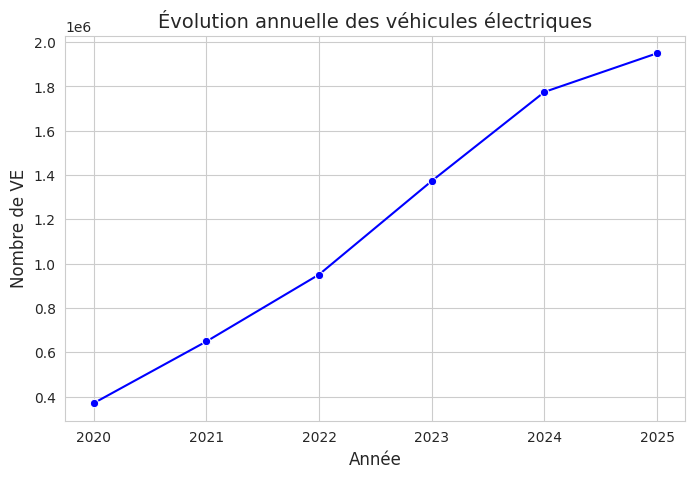

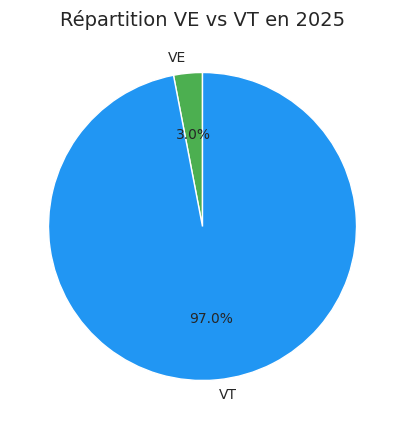

In [7]:
# ============================================================================
# IMPORTS & CONFIG
# ============================================================================

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import geopandas as gpd
import numpy as np


# ============================================================================
# Chargement & Préparation des données
# ============================================================================

bornes = pd.read_csv("../data/raw/BornesPropres.csv", low_memory=False) 
vehicules = pd.read_csv("../data/raw/voitures_par_commune_cleaned.csv", low_memory=False)
population = pd.read_csv("../data/clean/population_with_geopoint.csv", low_memory=False)

# dates et types
bornes["date_mise_en_service"] = pd.to_datetime(bornes["date_mise_en_service"], errors="coerce")

vehicules["code_commune"] = vehicules["code_commune"].astype(str).str.zfill(5)  # code commune sur 5 chiffres
vehicules["date_recensement"] = pd.to_datetime(vehicules["date_recensement"], errors="coerce") # date
vehicules["departement"] = vehicules["departement"].astype(str).str.strip().str.upper() # departement
vehicules["nb_voit_elec"] = pd.to_numeric(vehicules["nb_voit_elec"], errors="coerce") # nb voitures elec
vehicules["nb_voit_total"] = pd.to_numeric(vehicules["nb_voit_total"], errors="coerce") # nb voitures

# population
population["departement"] = population["Département"].astype(str).str.strip().str.upper() # departement

cols_to_num = [
    "0 à 19 ans", "20 à 39 ans", "40 à 59 ans",
    "60 à 74 ans", "75 ans et plus", "Total"
]

for col in cols_to_num:
    population[col] = (
        population[col]
        .astype(str)                              # force en string pour nettoyage
        .str.replace(r"\s", "", regex=True)       # supprime tous les espaces
        .str.replace(",", ".", regex=False)       # remplace les virgules par des points si besoin
        .replace({"-": None, "nc": None})         # gère les valeurs non numériques
        .astype(float)                            # convertit en float
    )


# Nouvelles colonnes dates (annee, mois, jour)
def extraire_date_datetime(df, colonne_date, prefix=""):
    """
    Crée des colonnes 'annee', 'mois', 'jour' en type datetime.date à partir d'une colonne datetime.
    prefix : préfixe pour les nouvelles colonnes
    """
    col_prefix = f"_{prefix}" if prefix else ""
    df[f'annee{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.year.astype('Int64')
    df[f'mois{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.month.astype('Int64')
    df[f'jour{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.day.astype('Int64')
    df[f'date{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.date  # version date
    return df

# Application aux bornes et véhicules
bornes = extraire_date_datetime(bornes, 'date_mise_en_service', prefix='mes')
vehicules = extraire_date_datetime(vehicules, 'date_recensement', prefix='recensement')

# ============================================================================
# Jointure VEHICULES & POPULATION
# ============================================================================

# Vérifier les départements communs
set_pop = set(population['departement'].unique())
set_vehicules = set(vehicules['departement'].unique())

# Visualiser
print("Départements communs population / véhicules :", len(set_pop & set_vehicules))


# Effectuer la jointure
vehicule_pop = vehicules.merge(
    population,
    on='departement',
    how='inner'  # inner = seulement les départements présents dans les deux jeux
)

# ============================================================================
# Jointure BORNES & POPULATION
# ============================================================================

# --- Nettoyage BORNES ---

# Création GeoDataFrames en WGS84
gdf_bornes = gpd.GeoDataFrame(
    bornes,
    geometry=gpd.points_from_xy(bornes['consolidated_longitude'], bornes['consolidated_latitude']),
    crs="EPSG:4326"
)

gdf_population = gpd.GeoDataFrame(
    population,
    geometry=gpd.points_from_xy(population['longitude_decimal'], population['latitude_decimal']),
    crs="EPSG:4326"
)

# Reprojection dans Lambert 93 (mètres) pour distance en mètres
gdf_bornes = gdf_bornes.to_crs(2154)
gdf_population = gdf_population.to_crs(2154)


# ---  Jointure par proximité ---
bornes_pop = gpd.sjoin_nearest(
    gdf_bornes,
    gdf_population,
    how='left',
    max_distance=60000,
    rsuffix='_pop'  # suffixe ajouté pour les colonnes du gdf_population
)

# --- Diagnostic : bornes sans correspondance ---
bornes_sans_pop = bornes_pop[bornes_pop['Total'].isna()]

print(f"Bornes totales : {len(bornes_pop)}")
print(f"Bornes sans correspondance : {len(bornes_sans_pop)} "
      f"({len(bornes_sans_pop)/len(bornes_pop)*100:.1f}%)")

# Extraction des coordonnées x et y depuis la colonne geometry
bornes_sans_pop = bornes_sans_pop.assign(
    x=bornes_sans_pop.geometry.x,
    y=bornes_sans_pop.geometry.y
)

# ============================================================================
# Gestion des données cumulées dans vehicules_pop
# ============================================================================

# Dernier relevé de chaque commune pour chaque année
vehicule_pop_last = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement'])
                .last()
                .reset_index()
)

# Dernier relevé de chaque commune pour chaque mois
vehicule_pop_last_month = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement', 'mois_recensement'])
                .last()
                .reset_index()
)

# Visualisation
# print(vehicule_pop_last.head())
# print(vehicule_pop_last_month.head())


# Agrégation des VE au niveau départemental
ve_par_dep = vehicule_pop_last.groupby('departement')['nb_voit_elec'].sum().reset_index()

# Agrégation des VT au niveau départemental
ve_par_dep_total = vehicule_pop_last.groupby('departement')['nb_voit_total'].sum().reset_index()

# Visualisation
# print(ve_par_dep.head())
# print(ve_par_dep_total.head())


# KPI VE annuel 
kpi_ve_annuel = vehicule_pop_last.groupby('annee_recensement').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# KPI VE mensuel 
kpi_ve_mensuel = vehicule_pop_last_month.groupby(['annee_recensement','mois_recensement']).agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# ============================================================================  
# 📊 KPI GÉNÉRAUX – PARC ET INFRASTRUCTURES (version corrigée)
# ============================================================================

print("\n" + "="*50)
print("📊 KPI GÉNÉRAUX")
print("="*50)

# --- Conversion date et extraction année ---
vehicule_pop['date_recensement'] = pd.to_datetime(vehicule_pop['date_recensement'])
vehicule_pop['annee'] = vehicule_pop['date_recensement'].dt.year

# --- Dernières dates de recensement par département pour 2025 ---
dernieres_dates_2025 = vehicule_pop[vehicule_pop['annee'] == 2025].groupby('departement')['date_recensement'].max().reset_index()
vehicule_2025_latest = vehicule_pop.merge(dernieres_dates_2025, on=['departement','date_recensement'], how='inner')

# --- Totaux VE / VT cohérents ---
nb_vt_total = vehicule_2025_latest['nb_voit_total'].sum()
nb_ve_total = vehicule_2025_latest['nb_voit_elec'].sum()
pct_ve_vs_vt = (nb_ve_total / nb_vt_total * 100) if nb_vt_total else 0

print(f"🔢 Total VT en 2025 : {nb_vt_total:,} VT")
print(f"🚗 Total VE en 2025 : {nb_ve_total:,} VE")
print(f"📊 Les VE représentent {pct_ve_vs_vt:.1f}% du parc total de véhicules")

# ---
vehicule_pop['date_recensement'] = pd.to_datetime(vehicule_pop['date_recensement'])
vehicule_pop['annee'] = vehicule_pop['date_recensement'].dt.year
dernieres_dates_dep = vehicule_pop.groupby(['annee', 'departement'])['date_recensement'].max().reset_index()
vehicule_latest = vehicule_pop.merge(dernieres_dates_dep, on=['annee','departement','date_recensement'], how='inner')
cumul_vehicules_annuel = vehicule_latest.groupby('annee').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_vt=('nb_voit_total', 'sum')
).reset_index()

# Croissance annuelle
cumul_vehicules_annuel['croissance_ve_%'] = cumul_vehicules_annuel['total_ve'].pct_change() * 100
cumul_vehicules_annuel['croissance_vt_%'] = cumul_vehicules_annuel['total_vt'].pct_change() * 100
cumul_vehicules_annuel['nouvelles_immats_ve'] = cumul_vehicules_annuel['total_ve'].diff()

# --- Année record en immatriculations VE ---
annee_record_ve = cumul_vehicules_annuel.loc[cumul_vehicules_annuel['nouvelles_immats_ve'].idxmax(),'annee']
print(f"🏆 Année record en immatriculations VE : {annee_record_ve}")

# --- Croissance VE / VT depuis la première année ---
croissance_ve = (cumul_vehicules_annuel['total_ve'].iloc[-1] - cumul_vehicules_annuel['total_ve'].iloc[0]) / cumul_vehicules_annuel['total_ve'].iloc[0] * 100
print(f"🚗 Évolution du parc VE : {croissance_ve:,.1f} %")

# ============================================================================ 
# 3. GRAPHS
# ============================================================================

# --- Assurer uniformité esthétique ---
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (8,5), 'axes.titlesize':14, 'axes.labelsize':12})

# ===================================================================
# 0️⃣ Préparation des colonnes nécessaires
# ===================================================================
# Création colonne 'annee' pour vehicule_pop
if 'annee' not in vehicule_pop.columns:
    vehicule_pop['annee'] = pd.to_datetime(vehicule_pop['date_recensement']).dt.year


# ===================================================================
# 1️⃣ Evolution annuelle du parc VE (corrigé)
# ===================================================================

# Dernière date connue par département et par année
dernieres_dates = vehicule_pop.groupby(['annee', 'departement'])['date_recensement'].max().reset_index()
vehicule_latest = vehicule_pop.merge(dernieres_dates, on=['annee','departement','date_recensement'], how='inner')

# Totaux VE par année
df_ve_annee = vehicule_latest.groupby('annee')['nb_voit_elec'].sum().reset_index()

# Graphique
plt.figure()
sns.lineplot(data=df_ve_annee, x='annee', y='nb_voit_elec', marker='o', color='blue')
plt.title("Évolution annuelle des véhicules électriques")
plt.ylabel("Nombre de VE")
plt.xlabel("Année")
plt.grid(True)
plt.show()


# ===================================================================
# 3️⃣ Répartition VE vs VT (2025)
# ===================================================================
sizes = [nb_ve_total, nb_vt_total - nb_ve_total]
plt.figure()
plt.pie(sizes, labels=['VE','VT'], autopct='%1.1f%%', startangle=90, colors=['#4CAF50','#2196F3'])
plt.title("Répartition VE vs VT en 2025")
plt.show()



📊 KPI GÉNÉRAUX
🔢 Total VT en 2025 : 64,618,583 VT
🚗 Total VE en 2025 : 1,950,279 VE
📊 Les VE représentent 3.0% du parc total de véhicules
🚗 Évolution du parc VE : 427.5 %


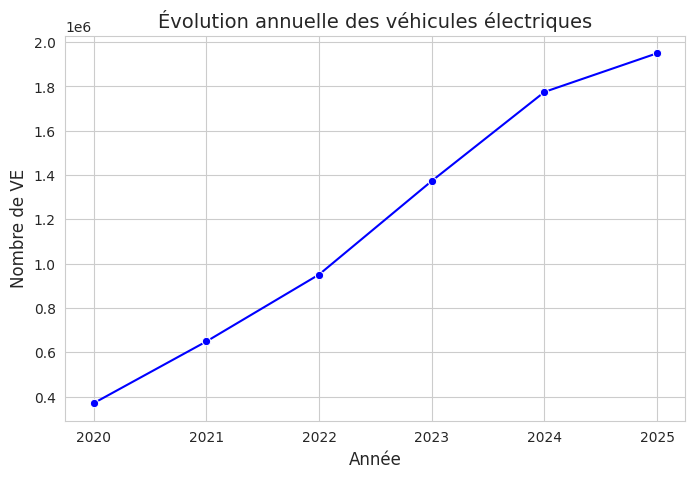

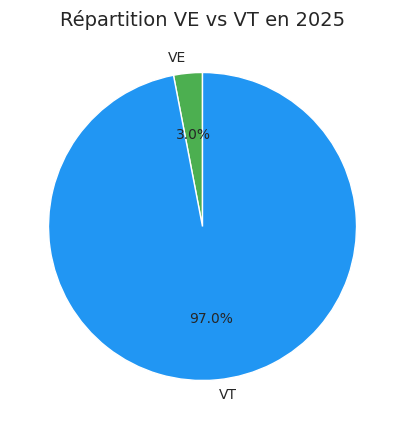

In [11]:
# ============================================================================
# IMPORTS & CONFIG
# ============================================================================

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import numpy as np

# ============================================================================
# Chargement & Préparation des données
# ============================================================================

bornes = pd.read_csv("../data/raw/BornesPropres.csv", low_memory=False) 
vehicules = pd.read_csv("../data/raw/voitures_par_commune_cleaned.csv", low_memory=False)
population = pd.read_csv("../data/clean/population_with_geopoint.csv", low_memory=False)

# dates et types
bornes["date_mise_en_service"] = pd.to_datetime(bornes["date_mise_en_service"], errors="coerce")

vehicules["code_commune"] = vehicules["code_commune"].astype(str).str.zfill(5)
vehicules["date_recensement"] = pd.to_datetime(vehicules["date_recensement"], errors="coerce")
vehicules["departement"] = vehicules["departement"].astype(str).str.strip().str.upper()
vehicules["nb_voit_elec"] = pd.to_numeric(vehicules["nb_voit_elec"], errors="coerce")
vehicules["nb_voit_total"] = pd.to_numeric(vehicules["nb_voit_total"], errors="coerce")

# population
population["departement"] = population["Département"].astype(str).str.strip().str.upper()

cols_to_num = ["0 à 19 ans", "20 à 39 ans", "40 à 59 ans", "60 à 74 ans", "75 ans et plus", "Total"]
for col in cols_to_num:
    population[col] = (
        population[col]
        .astype(str)
        .str.replace(r"\s", "", regex=True)
        .str.replace(",", ".", regex=False)
        .replace({"-": None, "nc": None})
        .astype(float)
    )

# Nouvelles colonnes dates
def extraire_date_datetime(df, colonne_date, prefix=""):
    col_prefix = f"_{prefix}" if prefix else ""
    df[f'annee{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.year.astype('Int64')
    df[f'mois{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.month.astype('Int64')
    df[f'jour{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.day.astype('Int64')
    df[f'date{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.date
    return df

bornes = extraire_date_datetime(bornes, 'date_mise_en_service', prefix='mes')
vehicules = extraire_date_datetime(vehicules, 'date_recensement', prefix='recensement')

# ============================================================================
# Jointure VEHICULES & POPULATION
# ============================================================================

vehicule_pop = vehicules.merge(
    population,
    on='departement',
    how='inner'
)

# ============================================================================
# Jointure BORNES & POPULATION
# ============================================================================

gdf_bornes = gpd.GeoDataFrame(
    bornes,
    geometry=gpd.points_from_xy(bornes['consolidated_longitude'], bornes['consolidated_latitude']),
    crs="EPSG:4326"
)

gdf_population = gpd.GeoDataFrame(
    population,
    geometry=gpd.points_from_xy(population['longitude_decimal'], population['latitude_decimal']),
    crs="EPSG:4326"
)

gdf_bornes = gdf_bornes.to_crs(2154)
gdf_population = gdf_population.to_crs(2154)

bornes_pop = gpd.sjoin_nearest(
    gdf_bornes,
    gdf_population,
    how='left',
    max_distance=60000,
    rsuffix='_pop'
)

# ============================================================================
# Gestion des données cumulées dans vehicules_pop
# ============================================================================

vehicule_pop_last = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement'])
                .last()
                .reset_index()
)

vehicule_pop_last_month = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement', 'mois_recensement'])
                .last()
                .reset_index()
)

# KPI VE annuel
kpi_ve_annuel = vehicule_pop_last.groupby('annee_recensement').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# KPI VE mensuel
kpi_ve_mensuel = vehicule_pop_last_month.groupby(['annee_recensement','mois_recensement']).agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# ============================================================================
# 📊 KPI GÉNÉRAUX – PARC ET INFRASTRUCTURES
# ============================================================================

print("\n" + "="*50)
print("📊 KPI GÉNÉRAUX")
print("="*50)

vehicule_pop['date_recensement'] = pd.to_datetime(vehicule_pop['date_recensement'])
vehicule_pop['annee'] = vehicule_pop['date_recensement'].dt.year

dernieres_dates_2025 = vehicule_pop[vehicule_pop['annee'] == 2025].groupby('departement')['date_recensement'].max().reset_index()
vehicule_2025_latest = vehicule_pop.merge(dernieres_dates_2025, on=['departement','date_recensement'], how='inner')

nb_vt_total = vehicule_2025_latest['nb_voit_total'].sum()
nb_ve_total = vehicule_2025_latest['nb_voit_elec'].sum()
pct_ve_vs_vt = (nb_ve_total / nb_vt_total * 100) if nb_vt_total else 0

print(f"🔢 Total VT en 2025 : {nb_vt_total:,} VT")
print(f"🚗 Total VE en 2025 : {nb_ve_total:,} VE")
print(f"📊 Les VE représentent {pct_ve_vs_vt:.1f}% du parc total de véhicules")

dernieres_dates_dep = vehicule_pop.groupby(['annee', 'departement'])['date_recensement'].max().reset_index()
vehicule_latest = vehicule_pop.merge(dernieres_dates_dep, on=['annee','departement','date_recensement'], how='inner')
cumul_vehicules_annuel = vehicule_latest.groupby('annee').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_vt=('nb_voit_total', 'sum')
).reset_index()

cumul_vehicules_annuel['croissance_ve_%'] = cumul_vehicules_annuel['total_ve'].pct_change() * 100
cumul_vehicules_annuel['croissance_vt_%'] = cumul_vehicules_annuel['total_vt'].pct_change() * 100
cumul_vehicules_annuel['nouvelles_immats_ve'] = cumul_vehicules_annuel['total_ve'].diff()

croissance_ve = (cumul_vehicules_annuel['total_ve'].iloc[-1] - cumul_vehicules_annuel['total_ve'].iloc[0]) / cumul_vehicules_annuel['total_ve'].iloc[0] * 100
print(f"🚗 Évolution du parc VE : {croissance_ve:,.1f} %")

# ============================================================================
# 3. GRAPHS
# ============================================================================

sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (8,5), 'axes.titlesize':14, 'axes.labelsize':12})

# Evolution annuelle du parc VE
df_ve_annee = vehicule_latest.groupby('annee')['nb_voit_elec'].sum().reset_index()
plt.figure()
sns.lineplot(data=df_ve_annee, x='annee', y='nb_voit_elec', marker='o', color='blue')
plt.title("Évolution annuelle des véhicules électriques")
plt.ylabel("Nombre de VE")
plt.xlabel("Année")
plt.grid(True)
plt.show()

# Répartition VE vs VT (2025)
sizes = [nb_ve_total, nb_vt_total - nb_ve_total]
plt.figure()
plt.pie(sizes, labels=['VE','VT'], autopct='%1.1f%%', startangle=90, colors=['#4CAF50','#2196F3'])
plt.title("Répartition VE vs VT en 2025")
plt.show()
